# Iris Classifier — Building Your First AI Model

An end-to-end **supervised machine learning** project: predict the species of an Iris flower
(*setosa*, *versicolor*, or *virginica*) from four measurements — sepal length, sepal width,
petal length, and petal width (all in cm).

**Workflow:** prepare data → train a model → make predictions → evaluate → interpret.

We use the classic Iris dataset (150 samples, 50 per species) and a **Decision Tree classifier**
from scikit-learn — simple, fast, and highly interpretable.

In [1]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42  # deterministic shuffle -> reproducible results

## Step 1 — Preparing the data

scikit-learn ships the Iris dataset. We load it, inspect the features and targets,
and keep a local CSV copy in `data/iris.csv` for reproducibility.

In [2]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

print("Feature names:", feature_names)
print("Target names:", target_names)
print("Data shape:", X.shape)

# Save a local copy of the dataset
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = repo_root / "data" / "iris.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)
df = pd.DataFrame(X, columns=feature_names)
df["species"] = y
df.to_csv(data_path, index=False)
print(f"Local dataset copy: {data_path}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Data shape: (150, 4)
Local dataset copy: /sessions/fervent-peaceful-noether/mnt/IT_Career_switch/irisclassifier/data/iris.csv


In [3]:
# Quick exploration: first samples and summary statistics
display(df.head())
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


The dataset is balanced (50 samples per species) and clean — no missing values.
Petal length is much smaller for *setosa* than for the other species, so it should be a very
informative feature. All features share the same unit (cm), so **feature scaling is not needed**
for a decision tree, and we use all four features as-is.

In [4]:
# Split into training and test sets (80/20 -> 120 train / 30 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

Training samples: 120 | Test samples: 30


## Step 2 — Choosing and training a model

A **Decision Tree classifier**: it learns human-readable rules
(e.g. *"if petal length < 2.45 cm → setosa"*), works well on small datasets, and trains in
milliseconds. Training uses scikit-learn's uniform `.fit(X, y)` API.

In [5]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 3 — Making predictions

We predict species for the 30 **test samples the model has never seen** and compare a few
predictions against the true labels.

In [6]:
y_pred = model.predict(X_test)
print("First 5 predicted:", [target_names[i] for i in y_pred[:5]])
print("First 5 actual:   ", [target_names[i] for i in y_test[:5]])

First 5 predicted: [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]
First 5 actual:    [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]


## Step 4 — Evaluating the model

**Accuracy** = fraction of correct predictions. The **confusion matrix** breaks results down
per class: rows = actual species, columns = predicted species; the diagonal holds correct
predictions.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy:.0%})")

Accuracy: 1.0000 (100%)


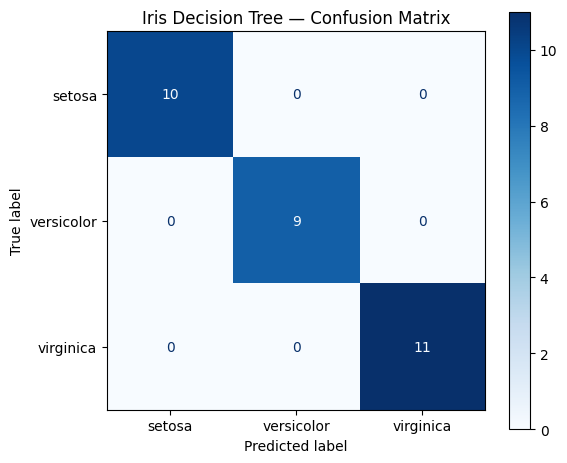

Figure saved to /sessions/fervent-peaceful-noether/mnt/IT_Career_switch/irisclassifier/outputs/confusion_matrix.png


In [8]:
# Confusion matrix — displayed and saved to outputs/confusion_matrix.png
out_dir = repo_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)  # created programmatically

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Iris Decision Tree — Confusion Matrix")
fig.tight_layout()
fig.savefig(out_dir / "confusion_matrix.png", dpi=150)
plt.show()
print(f"Figure saved to {out_dir / 'confusion_matrix.png'}")

In [9]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Interpreting the model

Decision trees are transparent: we can inspect which features drive the decisions and
visualize the learned rules.

In [10]:
# Feature importances
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.round(3))

petal length (cm)    0.906
petal width (cm)     0.077
sepal width (cm)     0.017
sepal length (cm)    0.000
dtype: float64


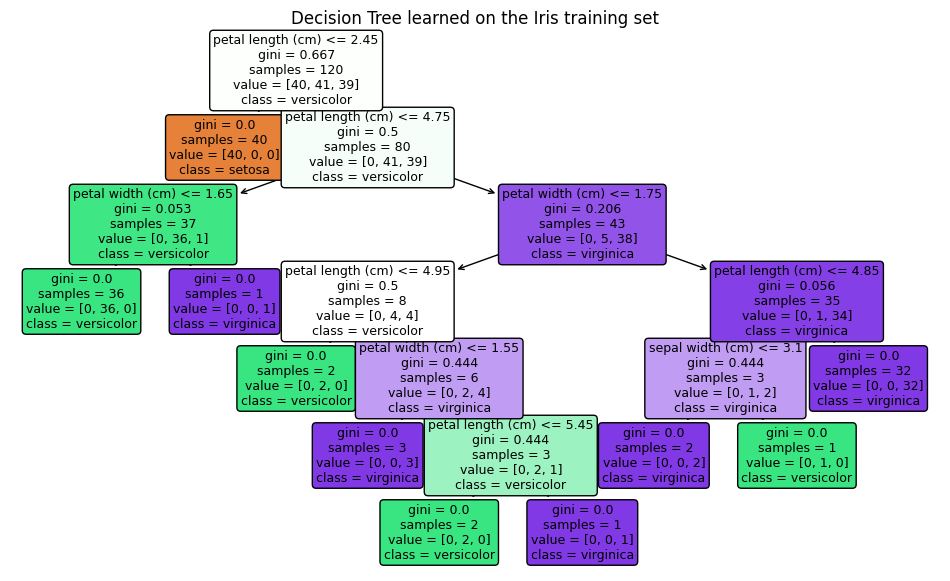

In [11]:
# Visualize the learned decision rules
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(12, 7))
plot_tree(model, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree learned on the Iris training set")
plt.show()

## Results and conclusions

- With the 80/20 split (`random_state=42`), the decision tree classified **all 30 test
  samples correctly — accuracy = 1.00 (100%)**. The confusion matrix is fully diagonal:
  10 setosa, 9 versicolor, and 11 virginica, with zero misclassifications. Results in the
  95–100% range are typical for Iris; on other splits the model occasionally confuses
  *versicolor* and *virginica*, the two most similar species.
- **Petal measurements dominate:** petal length (~0.91) and petal width (~0.08) carry nearly
  all the feature importance, while sepal dimensions contribute almost nothing. This matches
  botanical intuition — the tree's first split (petal length ≤ 2.45 cm) isolates *setosa*
  perfectly.
- **Caution:** the test set is small (30 samples), and an unpruned tree can memorize training
  data (overfitting). Cross-validation or limiting tree depth (`max_depth`) would give a more
  robust performance estimate.
- **Next iterations:** try other algorithms (KNN, SVM), tune hyperparameters with
  `GridSearchCV`, or engineer features (e.g. petal length/width ratio).